# Ejercicio 1 — ¿Por qué hace falta globalizar?

**Métodos Numéricos II (DAT-252) — UMSA**
Estrategias para la convergencia global · Métodos de Newton-Krylov

El método de Newton converge cuadráticamente, pero **solo localmente**. Este notebook
lo muestra con las manos y comprueba que una estrategia de globalización barata
convierte un método que diverge en uno que converge.

| Parte | Qué muestra |
|---|---|
| A | `arctan(x) = 0` desde `x0 = 2`: el paso de Newton se dispara |
| B | Sistema 2×2: Newton puro desborda, Armijo y región de confianza llegan |
| C | Cuencas de convergencia con presupuesto de 12 iteraciones |
| D | Dónde la globalización **también** falla |
| E | Cuencas comparadas: el caso donde Newton puro gana |
| F | El parámetro α de la condición de Armijo |

In [1]:
import os, warnings
import numpy as np

import nk_lib
from nk_lib import estilo_figuras, tabla, titulo

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt = estilo_figuras()          # estilo común de las figuras del trabajo
%matplotlib inline

SALIDA = "figuras"
os.makedirs(SALIDA, exist_ok=True)

## Parte A · arctan(x) = 0 — Newton se dispara desde x₀ = 2


  PARTE A · arctan(x) = 0 — Newton se dispara desde x0 = 2

  La raíz es x* = 0 y arctan es suave y monótona: parece inofensiva.
  Pero arctan se aplana lejos del origen, así que la tangente cruza el eje
  MUY lejos y el paso de Newton x - f(x)/f'(x) sobrepasa la raíz cada vez
  más. El umbral es |x0| ≈ 1.3917: por encima, Newton puro diverge.

  ------+-----------------+-----------
    x0  | x tras 12 pasos | resultado 
  ------+-----------------+-----------
   1.00 |   +0.0000e+00   |  converge 
   1.30 |   +0.0000e+00   |  converge 
   1.50 |   -2.3830e+13   |  DIVERGE  
   2.00 |   +8.5908e+20   |  DIVERGE  
  ------+-----------------+-----------

  Newton puro  desde x0=2 : ['2', '-3.54', '14', '-279', '1.22e+05', '-2.34e+10'] ...
  Newton+Armijo desde x0=2 : ['2', '-0.768', '0.273', '-0.0134', '1.6e-06', '-2.75e-18'] ...
  λ usados por Armijo      : ['0.500', '1.000', '1.000', '1.000', '1.000']

  Newton puro : NO convergió
  Con Armijo  : convergió en 5 iteraciones


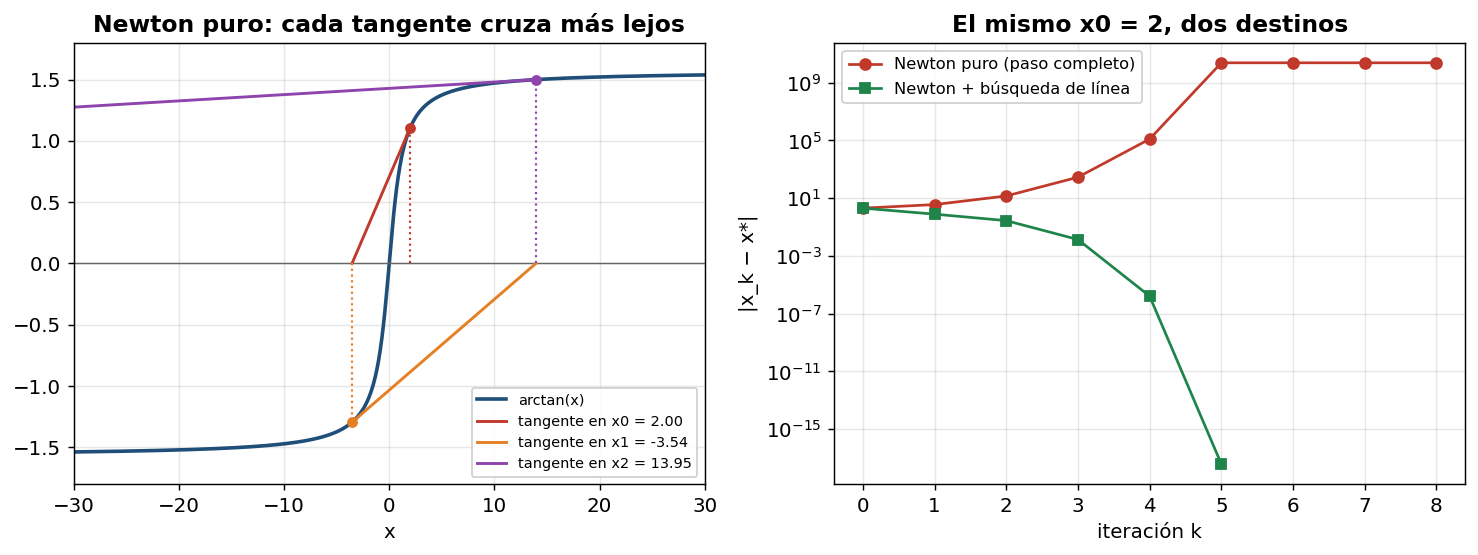


  → figuras/fig1a_arctan.png


In [2]:
titulo("PARTE A · arctan(x) = 0 — Newton se dispara desde x0 = 2")

f = np.arctan
fp = lambda x: 1.0 / (1.0 + x * x)

print("""
  La raíz es x* = 0 y arctan es suave y monótona: parece inofensiva.
  Pero arctan se aplana lejos del origen, así que la tangente cruza el eje
  MUY lejos y el paso de Newton x - f(x)/f'(x) sobrepasa la raíz cada vez
  más. El umbral es |x0| ≈ 1.3917: por encima, Newton puro diverge.
""")

filas = []
for x0 in (1.0, 1.3, 1.5, 2.0):
    x = x0
    for _ in range(12):
        x = x - f(x) / fp(x)
        if not np.isfinite(x) or abs(x) > 1e12:
            break
    estado = "converge" if abs(x) < 1e-8 else "DIVERGE"
    filas.append([f"{x0:.2f}", f"{x:+.4e}" if np.isfinite(x) else "overflow", estado])
tabla(filas, ["x0", "x tras 12 pasos", "resultado"])

# --- Iteraciones desde x0 = 2, con y sin búsqueda de línea ---
def F(v):
    return np.arctan(v)

h_puro = nk_lib.newton_krylov(F, np.array([2.0]), globalizacion="ninguna",
                              forzado=1e-12, tol=1e-12, max_iter=8,
                              guardar_trayectoria=True)
h_line = nk_lib.newton_krylov(F, np.array([2.0]), globalizacion="linea",
                              forzado=1e-12, tol=1e-12, max_iter=8,
                              guardar_trayectoria=True)
it_puro = [p[0] for p in h_puro.trayectoria]
it_line = [p[0] for p in h_line.trayectoria]

print(f"\n  Newton puro  desde x0=2 : {['%.3g' % v for v in it_puro[:6]]} ...")
print(f"  Newton+Armijo desde x0=2 : {['%.3g' % v for v in it_line[:6]]} ...")
print(f"  λ usados por Armijo      : {['%.3f' % v for v in h_line.lambdas]}")
print(f"\n  Newton puro : {'convergió' if h_puro.convergio else 'NO convergió'}")
print(f"  Con Armijo  : {'convergió' if h_line.convergio else 'NO convergió'}"
      f" en {h_line.n_newton} iteraciones")

# --- Figura: la construcción geométrica del disparo ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))

xs = np.linspace(-30, 30, 800)
a1.plot(xs, np.arctan(xs), color="#1f4e79", lw=2, label="arctan(x)")
a1.axhline(0, color="0.4", lw=0.8)
colores = ["#c0392b", "#e67e22", "#8e44ad"]
for i in range(3):
    xk = it_puro[i]
    xk1 = it_puro[i + 1]
    a1.plot([xk, xk], [0, f(xk)], color=colores[i], ls=":", lw=1.2)
    a1.plot([xk, xk1], [f(xk), 0], color=colores[i], lw=1.6,
            label=f"tangente en x{i} = {xk:.2f}")
    a1.plot([xk], [f(xk)], "o", color=colores[i], ms=5)
a1.set_xlim(-30, 30)
a1.set_ylim(-1.8, 1.8)
a1.set_title("Newton puro: cada tangente cruza más lejos")
a1.set_xlabel("x")
a1.legend(fontsize=8, loc="lower right")

a2.semilogy(np.abs(np.array(it_puro)) + 1e-18, "o-", color="#c0392b",
            label="Newton puro (paso completo)")
a2.semilogy(np.abs(np.array(it_line)) + 1e-18, "s-", color="#1e8449",
            label="Newton + búsqueda de línea")
a2.set_xlabel("iteración k")
a2.set_ylabel("|x_k − x*|")
a2.set_title("El mismo x0 = 2, dos destinos")
a2.legend(fontsize=9)

fig.savefig(f"{SALIDA}/fig1a_arctan.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig1a_arctan.png")

## Parte B · Sistema 2×2 desde x₀ = (2.0, 0.5)

In [3]:
def F_kelley(v):
    """Sistema de prueba (Kelley, 2003):

        F1(x1,x2) = x1² + x2² − 2
        F2(x1,x2) = e^(x1−1) + x2³ − 2

    Raíz: x* = (1, 1). La segunda componente crece exponencialmente en x1,
    así que un paso de Newton demasiado largo hacia la derecha desborda.
    Además J es SINGULAR sobre la recta x2 = 0 (la segunda columna se anula),
    lo que usamos en la Parte D.
    """
    return np.array([v[0] ** 2 + v[1] ** 2 - 2.0,
                     np.exp(v[0] - 1.0) + v[1] ** 3 - 2.0])


def J_kelley(v):
    return np.array([[2.0 * v[0], 2.0 * v[1]],
                     [np.exp(v[0] - 1.0), 3.0 * v[1] ** 2]])


  PARTE B · Sistema 2×2 desde x0 = (2.0, 0.5)

F1 = x1² + x2² − 2                       raíz:  x* = (1, 1)
F2 = e^(x1−1) + x2³ − 2

  Las tres estrategias arrancan del MISMO punto y usan el MISMO paso de
  Newton. Lo único que cambia es cuánto de ese paso se acepta.

  ------------------------------+------------+-------+-----------+-------------+-------------------------
            estrategia          | ¿converge? | iters | ‖F‖ final | evals. de F |     motivo de parada    
  ------------------------------+------------+-------+-----------+-------------+-------------------------
           Newton puro          |     NO     |   16  |    inf    |     138     | divergió (‖F‖ desbordó) 
    Búsqueda de línea (Armijo)  |     sí     |   7   |  9.86e-12 |     108     |        convergió        
   Región de confianza (dogleg) |     sí     |   6   |  0.00e+00 |     799     |        convergió        
  ------------------------------+------------+-------+-----------+-------------+---------------

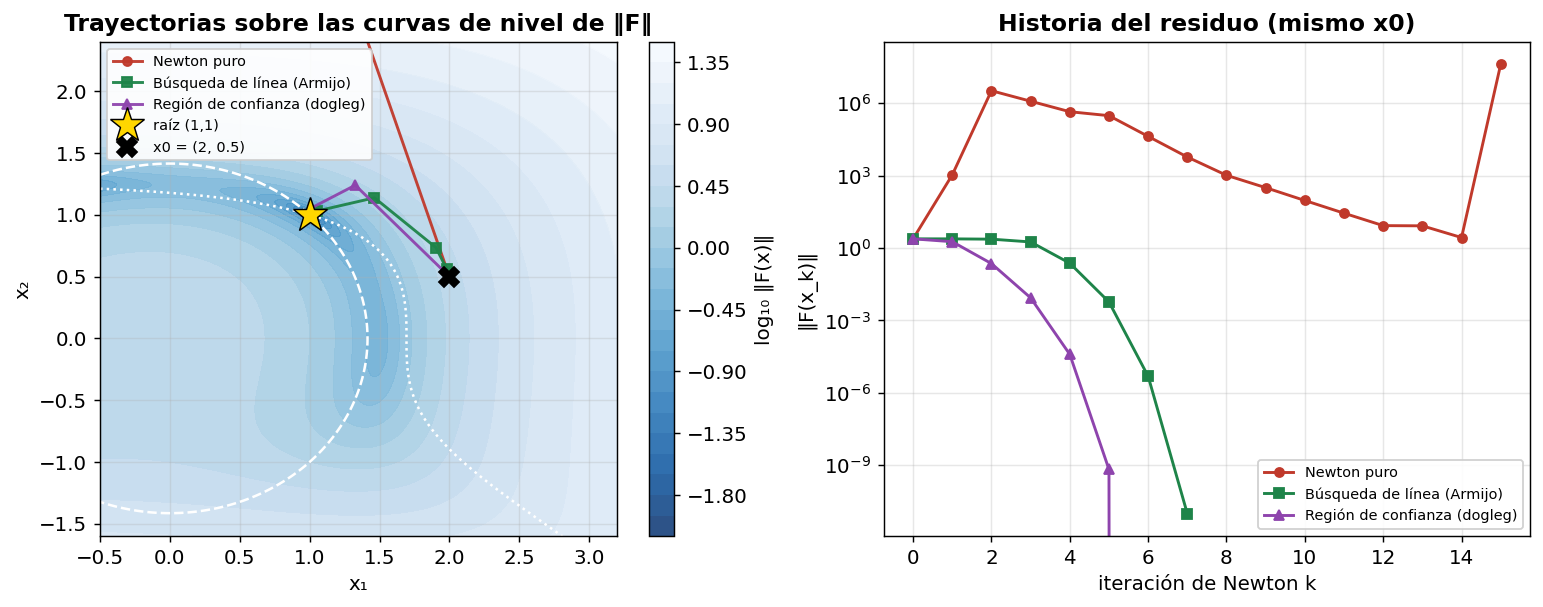


  → figuras/fig1b_trayectorias.png


In [4]:
titulo("PARTE B · Sistema 2×2 desde x0 = (2.0, 0.5)")

print("""
F1 = x1² + x2² − 2                       raíz:  x* = (1, 1)
F2 = e^(x1−1) + x2³ − 2

  Las tres estrategias arrancan del MISMO punto y usan el MISMO paso de
  Newton. Lo único que cambia es cuánto de ese paso se acepta.
""")

x0 = np.array([2.0, 0.5])
corridas = {}
for etiqueta, kw in [("Newton puro", dict(globalizacion="ninguna")),
                     ("Búsqueda de línea (Armijo)", dict(globalizacion="linea")),
                     ("Región de confianza (dogleg)", dict(globalizacion="region",
                                                           delta0=1.0))]:
    corridas[etiqueta] = nk_lib.newton_krylov(
        F_kelley, x0, forzado=1e-12, tol=1e-11, max_iter=30,
        guardar_trayectoria=True, **kw)

filas = []
for etiqueta, h in corridas.items():
    filas.append([etiqueta,
                  "sí" if h.convergio else "NO",
                  h.n_newton,
                  f"{h.residuales[-1]:.2e}",
                  h.n_F,
                  h.motivo])
tabla(filas, ["estrategia", "¿converge?", "iters", "‖F‖ final",
              "evals. de F", "motivo de parada"])

# --- Figura: trayectorias sobre las curvas de nivel de ‖F‖ ---
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))

g1 = np.linspace(-0.5, 3.2, 320)
g2 = np.linspace(-1.6, 2.4, 320)
G1, G2 = np.meshgrid(g1, g2)
Z = np.log10(np.sqrt((G1 ** 2 + G2 ** 2 - 2) ** 2 +
                     (np.exp(G1 - 1) + G2 ** 3 - 2) ** 2) + 1e-12)
cf = a1.contourf(G1, G2, Z, levels=28, cmap="Blues_r", alpha=0.85)
fig.colorbar(cf, ax=a1, label="log₁₀ ‖F(x)‖")
# las dos curvas F1 = 0 y F2 = 0; se cortan en la raíz
a1.contour(G1, G2, G1 ** 2 + G2 ** 2 - 2, levels=[0], colors="white",
           linewidths=1.4, linestyles="--")
a1.contour(G1, G2, np.exp(G1 - 1) + G2 ** 3 - 2, levels=[0], colors="white",
           linewidths=1.4, linestyles=":")

estilos = {"Newton puro": ("#c0392b", "o-"),
           "Búsqueda de línea (Armijo)": ("#1e8449", "s-"),
           "Región de confianza (dogleg)": ("#8e44ad", "^-")}
for etiqueta, h in corridas.items():
    color, marca = estilos[etiqueta]
    T = np.array(h.trayectoria)
    T = T[np.all(np.isfinite(T), axis=1)]
    a1.plot(T[:, 0], T[:, 1], marca, color=color, ms=5, lw=1.6,
            label=etiqueta, alpha=0.95)
a1.plot(1, 1, "*", color="gold", ms=20, mec="black", mew=0.8, label="raíz (1,1)")
a1.plot(*x0, "X", color="black", ms=11, label="x0 = (2, 0.5)")
a1.set_xlim(g1[0], g1[-1])
a1.set_ylim(g2[0], g2[-1])
a1.set_xlabel("x₁")
a1.set_ylabel("x₂")
a1.set_title("Trayectorias sobre las curvas de nivel de ‖F‖")
a1.legend(fontsize=8, loc="upper left")

for etiqueta, h in corridas.items():
    color, marca = estilos[etiqueta]
    r = np.array(h.residuales, dtype=float)
    r = np.where(np.isfinite(r), r, np.nan)
    a2.semilogy(r, marca, color=color, ms=5, lw=1.6, label=etiqueta)
a2.set_xlabel("iteración de Newton k")
a2.set_ylabel("‖F(x_k)‖")
a2.set_title("Historia del residuo (mismo x0)")
a2.legend(fontsize=8)

fig.savefig(f"{SALIDA}/fig1b_trayectorias.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig1b_trayectorias.png")

## Parte C · Mapa de cuencas con presupuesto de 12 iteraciones

In [5]:
def newton_2x2(x0, estrategia, max_iter=12, tol=1e-10):
    """Newton para n = 2 con el sistema lineal resuelto de forma exacta.

    Aquí NO usamos Krylov a propósito: en dimensión 2 resolver J s = −F es
    trivial, y lo que queremos aislar en esta parte es el efecto de la
    GLOBALIZACIÓN, no el del solver lineal. Devuelve (convergió, iteraciones).
    """
    x = np.array(x0, dtype=float)
    Fx = F_kelley(x)
    nF = np.linalg.norm(Fx)

    for k in range(max_iter):
        if nF <= tol:
            return True, k
        if not np.isfinite(nF) or nF > 1e12:
            return False, k
        J = J_kelley(x)
        if abs(np.linalg.det(J)) < 1e-13:
            return False, k
        s = np.linalg.solve(J, -Fx)

        if estrategia == "puro":
            x = x + s
            Fx = F_kelley(x)
            nF = np.linalg.norm(Fx)
        else:                                    # Armijo
            lam = 1.0
            for _ in range(40):
                x_t = x + lam * s
                F_t = F_kelley(x_t)
                n_t = np.linalg.norm(F_t)
                if n_t <= (1.0 - 1e-4 * lam) * nF:
                    break
                lam *= 0.5
            else:
                return False, k
            x, Fx, nF = x_t, F_t, n_t
    return nF <= tol, max_iter


  PARTE C · Mapa de cuencas con presupuesto de 12 iteraciones

  Barremos 51×51 = 2601 puntos iniciales y pintamos cada uno según cuántas
  iteraciones necesitó. El presupuesto es de 12 iteraciones: así se mide lo
  que de verdad importa en la práctica, no "¿converge alguna vez?" sino
  "¿converge con los recursos que tengo?".

  Dos aclaraciones de método, para que el experimento sea limpio:

· La ventana excluye la franja |x2| < 0.15. Ahí J es singular (Parte D) y
  lo que se mediría es el efecto de la singularidad, no el de globalizar.
· En dimensión 2 y con problemas suaves, Newton puro YA es bastante
  robusto. La diferencia aquí es real pero moderada. El abismo entre
  globalizar y no globalizar aparece en los sistemas grandes que vienen
  de discretizar una EDP: eso se ve en el ejercicio 3.



  -----------------+----------------------+------------+-----------------+----------------
      estrategia   | puntos que convergen | porcentaje | iters. medianas | iters. máximas 
  -----------------+----------------------+------------+-----------------+----------------
     Newton puro   |     2253 / 2601      |   86.6 %   |        6        |       12       
   Newton + Armijo |     2479 / 2601      |   95.3 %   |        6        |       12       
  -----------------+----------------------+------------+-----------------+----------------


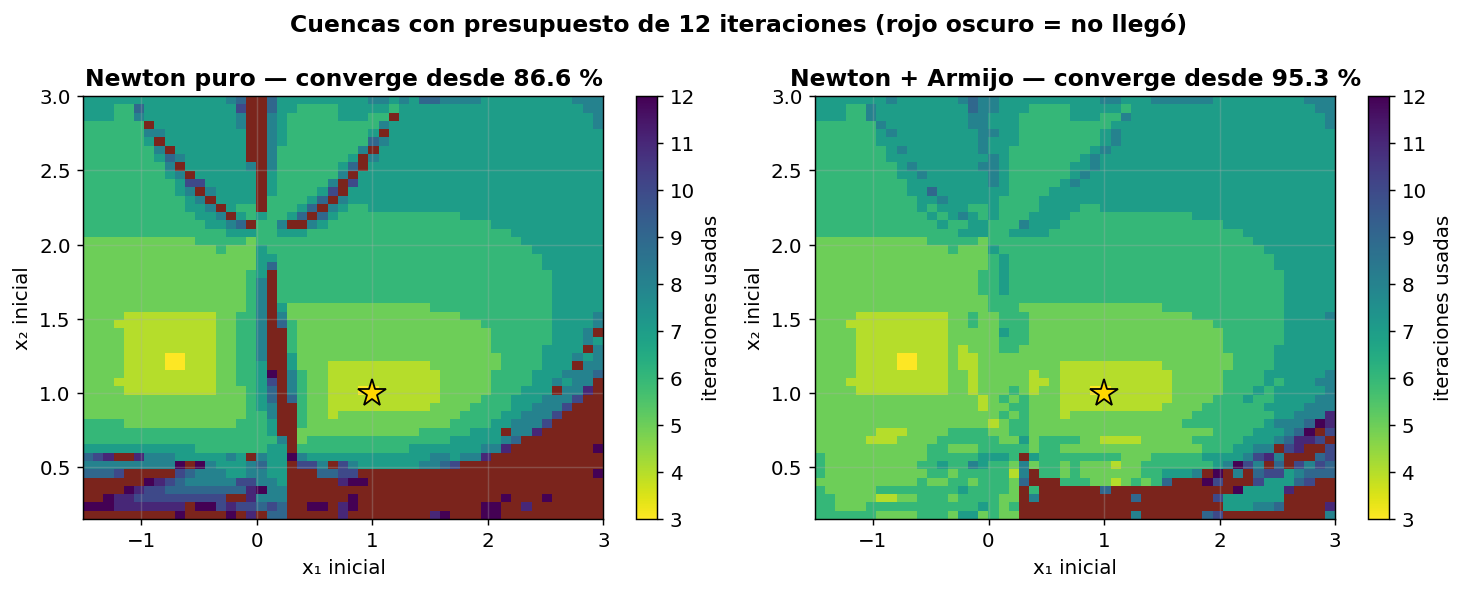


  → figuras/fig1c_cuencas.png


In [6]:
titulo("PARTE C · Mapa de cuencas con presupuesto de 12 iteraciones")

print("""
  Barremos 51×51 = 2601 puntos iniciales y pintamos cada uno según cuántas
  iteraciones necesitó. El presupuesto es de 12 iteraciones: así se mide lo
  que de verdad importa en la práctica, no "¿converge alguna vez?" sino
  "¿converge con los recursos que tengo?".

  Dos aclaraciones de método, para que el experimento sea limpio:

· La ventana excluye la franja |x2| < 0.15. Ahí J es singular (Parte D) y
  lo que se mediría es el efecto de la singularidad, no el de globalizar.
· En dimensión 2 y con problemas suaves, Newton puro YA es bastante
  robusto. La diferencia aquí es real pero moderada. El abismo entre
  globalizar y no globalizar aparece en los sistemas grandes que vienen
  de discretizar una EDP: eso se ve en el ejercicio 3.
""")

g1 = np.linspace(-1.5, 3.0, 51)
g2 = np.linspace(0.15, 3.0, 51)
mapas = {}
for estrategia in ("puro", "armijo"):
    M = np.zeros((len(g2), len(g1)))
    for i, b in enumerate(g2):
        for j, a in enumerate(g1):
            ok, it = newton_2x2((a, b), estrategia)
            M[i, j] = it if ok else np.nan
    mapas[estrategia] = M

filas = []
for estrategia, M in mapas.items():
    exito = np.count_nonzero(~np.isnan(M))
    filas.append(["Newton puro" if estrategia == "puro" else "Newton + Armijo",
                  f"{exito} / {M.size}",
                  f"{100*exito/M.size:.1f} %",
                  f"{np.nanmedian(M):.0f}",
                  f"{np.nanmax(M):.0f}"])
tabla(filas, ["estrategia", "puntos que convergen", "porcentaje",
              "iters. medianas", "iters. máximas"])

fig, ejes = plt.subplots(1, 2, figsize=(11.5, 4.6))
for ax, (estrategia, M) in zip(ejes, mapas.items()):
    nombre = "Newton puro" if estrategia == "puro" else "Newton + Armijo"
    im = ax.imshow(M, origin="lower", cmap="viridis_r",
                   extent=[g1[0], g1[-1], g2[0], g2[-1]],
                   aspect="auto", vmin=3, vmax=12)
    ax.set_facecolor("#7b241c")          # rojo oscuro = agotó el presupuesto
    pct = 100 * np.count_nonzero(~np.isnan(M)) / M.size
    ax.set_title(f"{nombre} — converge desde {pct:.1f} %")
    ax.plot(1, 1, "*", color="gold", ms=16, mec="black")
    ax.set_xlabel("x₁ inicial")
    ax.set_ylabel("x₂ inicial")
    fig.colorbar(im, ax=ax, label="iteraciones usadas")
fig.suptitle("Cuencas con presupuesto de 12 iteraciones "
             "(rojo oscuro = no llegó)", fontsize=13, fontweight="bold")
fig.savefig(f"{SALIDA}/fig1c_cuencas.png", bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig1c_cuencas.png")

## Parte D · Dónde la globalización TAMBIÉN falla

In [7]:
titulo("PARTE D · Dónde la globalización TAMBIÉN falla")

print("""
  El Jacobiano de este sistema es

    J = [ 2x1    2x2  ]
        [ e^(x1−1)  3x2² ]

  y sobre la recta x2 = 0 la segunda columna se anula: J es SINGULAR.
  La búsqueda de línea solo garantiza que ‖F‖ baje en cada paso; si el
  descenso arrastra la iteración hacia esa recta, el paso de Newton se hace
  enorme y mal condicionado, λ se va a cero y el método se atasca sin haber
  encontrado ninguna raíz. La región de confianza aguanta más porque acota
  el tamaño del paso, pero tampoco es una garantía.
""")

filas = []
for x0 in [(2.0, 0.5), (4.0, 0.0), (3.0, -1.0), (2.5, -2.0)]:
    fila = [str(x0)]
    for g, kw in [("ninguna", {}), ("linea", {}), ("region", dict(delta0=1.0))]:
        h = nk_lib.newton_krylov(F_kelley, np.array(x0), globalizacion=g,
                                 forzado=1e-12, tol=1e-11, max_iter=40, **kw)
        if h.convergio:
            fila.append(f"OK ({h.n_newton} it)")
        else:
            fila.append("falla")
    filas.append(fila)
tabla(filas, ["x0", "Newton puro", "Armijo", "Región (dogleg)"])

print("""
  Conclusión honesta para la exposición: la globalización garantiza que la
  función de mérito f(x) = ½‖F(x)‖² NO AUMENTE, y con eso convergencia a un
  punto estacionario de f. Un punto estacionario de f no tiene por qué ser
  una raíz de F: puede ser un mínimo local de f, o un punto donde J es
  singular. Eso es exactamente lo que dice el teorema, ni más ni menos.
""")


  PARTE D · Dónde la globalización TAMBIÉN falla

  El Jacobiano de este sistema es

    J = [ 2x1    2x2  ]
        [ e^(x1−1)  3x2² ]

  y sobre la recta x2 = 0 la segunda columna se anula: J es SINGULAR.
  La búsqueda de línea solo garantiza que ‖F‖ baje en cada paso; si el
  descenso arrastra la iteración hacia esa recta, el paso de Newton se hace
  enorme y mal condicionado, λ se va a cero y el método se atasca sin haber
  encontrado ninguna raíz. La región de confianza aguanta más porque acota
  el tamaño del paso, pero tampoco es una garantía.

  -------------+-------------+-----------+-----------------
        x0     | Newton puro |   Armijo  | Región (dogleg) 
  -------------+-------------+-----------+-----------------
    (2.0, 0.5) |    falla    | OK (7 it) |    OK (6 it)    
    (4.0, 0.0) |    falla    | OK (9 it) |    OK (8 it)    
   (3.0, -1.0) |    falla    |   falla   |    OK (8 it)    
   (2.5, -2.0) |  OK (11 it) |   falla   |      falla      
  -------------+-----

## Parte E · Cuencas comparadas: el caso donde Newton puro gana

Dos sistemas 2×2 distintos, cada uno resuelto con Newton puro y con Newton + Armijo,
barriendo 41×41 = 1681 puntos iniciales.

- **Problema A** — circunferencia contra exponencial empinada. La exponencial hace
  desbordar el paso completo.
- **Problema B** — función de Freudenstein y Roth. Su función de mérito tiene un
  **mínimo local** en `x₂ ≈ −0.8968` con `f ≈ 49 ≠ 0`. Un método que solo sabe bajar
  cae ahí y se queda.

In [8]:
def F_expo(v):
    """Circunferencia contra exponencial empinada."""
    return np.array([v[0]**2 + v[1]**2 - 4.0,
                     np.exp(3.0*v[0]) + v[1] - 1.0])

def J_expo(v):
    return np.array([[2.0*v[0], 2.0*v[1]],
                     [3.0*np.exp(3.0*v[0]), 1.0]])


def F_fr(v):
    """Función de Freudenstein y Roth (1963). Raíz única en (5, 4)."""
    return np.array([-13.0 + v[0] + ((5.0 - v[1])*v[1] - 2.0)*v[1],
                     -29.0 + v[0] + ((v[1] + 1.0)*v[1] - 14.0)*v[1]])

def J_fr(v):
    return np.array([[1.0, (10.0 - 3.0*v[1])*v[1] - 2.0],
                     [1.0, (3.0*v[1] + 2.0)*v[1] - 14.0]])


def newton_2d(F, J, x0, usar_armijo, max_iter=40, tol=1e-10, alpha=1e-4, lam_min=1e-10):
    """Newton para n = 2 con el sistema lineal resuelto de forma exacta."""
    x = np.array(x0, dtype=float)
    Fx = F(x)
    normaF = np.linalg.norm(Fx)
    lambdas = []

    for k in range(max_iter):
        if normaF <= tol:
            return "raiz", k, x, lambdas
        if not np.isfinite(normaF) or normaF > 1e12:
            return "desbordo", k, x, lambdas
        Jx = J(x)
        if abs(np.linalg.det(Jx)) < 1e-14:
            return "J singular", k, x, lambdas
        s = np.linalg.solve(Jx, -Fx)

        if not usar_armijo:
            lam = 1.0
            x = x + s
            Fx = F(x)
            normaF = np.linalg.norm(Fx)
        else:
            lam = 1.0
            aceptado = False
            while lam >= lam_min:
                x_t = x + lam*s
                F_t = F(x_t)
                n_t = np.linalg.norm(F_t)
                # "not (n_t <= cota)" y no "n_t > cota": con nan, el segundo aceptaría
                if n_t <= (1.0 - alpha*lam)*normaF:
                    aceptado = True
                    break
                lam = lam*0.5
            if not aceptado:
                return "linea fallo", k, x, lambdas
            x, Fx, normaF = x_t, F_t, n_t
        lambdas.append(lam)
    return "max iters", max_iter, x, lambdas


  PARTE E · Cuencas comparadas


  ------------+-----------------+------------------------
    problema  |    estrategia   | llega a una raíz desde 
  ------------+-----------------+------------------------
   Problema A |   Newton puro   |         98.0 %         
   Problema A | Newton + Armijo |        100.0 %         
   Problema B |   Newton puro   |         82.9 %         
   Problema B | Newton + Armijo |         36.6 %         
  ------------+-----------------+------------------------


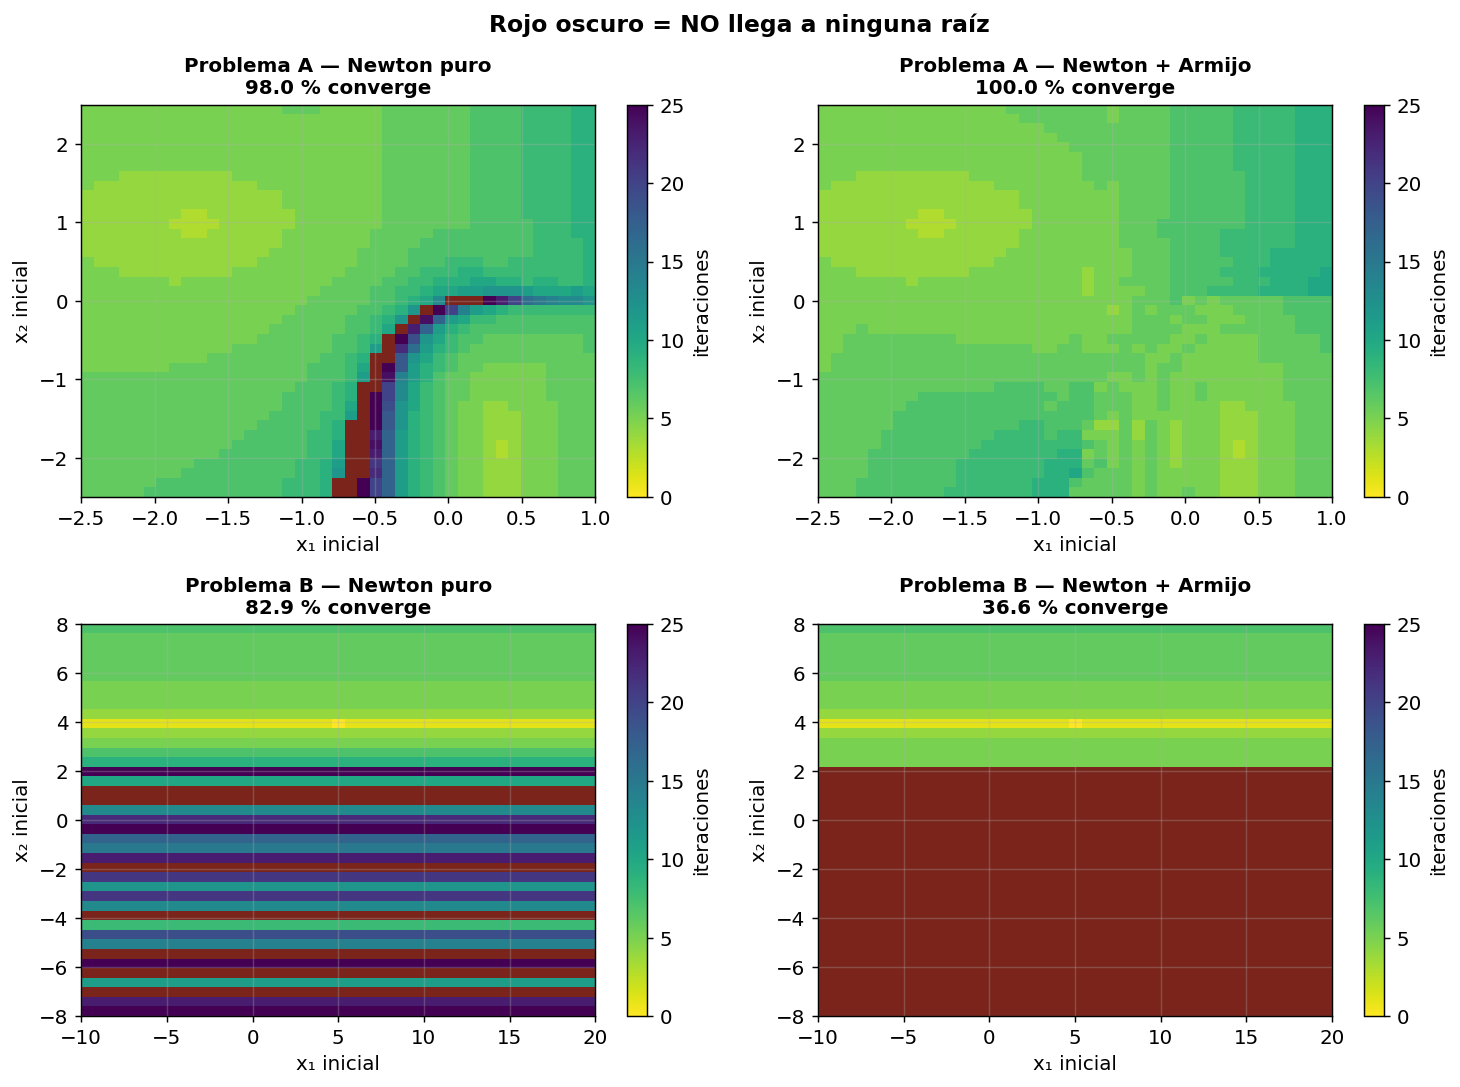


  → figuras/fig1d_cuencas_comparadas.png

  En el Problema B, Newton PURO gana. No es un error: la búsqueda de línea obliga a
  que ‖F‖ baje en cada paso, y eso la mete en el valle del mínimo local de f, del que
  ya no puede salir. Los pasos salvajes de Newton puro lo saltan por encima.



In [9]:
titulo("PARTE E · Cuencas comparadas")

config = [("A", F_expo, J_expo, (-2.5, 1.0, -2.5, 2.5)),
          ("B", F_fr,   J_fr,   (-10.0, 20.0, -8.0, 8.0))]

fig, ejes = plt.subplots(2, 2, figsize=(11.5, 8.5))
filas = []
for fila, (letra, F, J, caja) in enumerate(config):
    a, b, c, d = caja
    g1 = np.linspace(a, b, 41)
    g2 = np.linspace(c, d, 41)
    for col, usar_armijo in enumerate((False, True)):
        M = np.full((41, 41), np.nan)
        for i, q in enumerate(g2):
            for j, p in enumerate(g1):
                estado, its, _x, _l = newton_2d(F, J, (p, q), usar_armijo)
                if estado == "raiz":
                    M[i, j] = its
        pct = 100*np.count_nonzero(~np.isnan(M))/M.size
        nombre = "Newton + Armijo" if usar_armijo else "Newton puro"
        filas.append([f"Problema {letra}", nombre, f"{pct:.1f} %"])

        ax = ejes[fila, col]
        im = ax.imshow(M, origin="lower", cmap="viridis_r", aspect="auto",
                       extent=[a, b, c, d], vmin=0, vmax=25)
        ax.set_facecolor("#7b241c")
        ax.set_title(f"Problema {letra} — {nombre}\n{pct:.1f} % converge", fontsize=11)
        ax.set_xlabel("x₁ inicial")
        ax.set_ylabel("x₂ inicial")
        fig.colorbar(im, ax=ax, label="iteraciones")

tabla(filas, ["problema", "estrategia", "llega a una raíz desde"])
fig.suptitle("Rojo oscuro = NO llega a ninguna raíz", fontsize=13, fontweight="bold")
fig.tight_layout()
fig.savefig(f"{SALIDA}/fig1d_cuencas_comparadas.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"\n  → {SALIDA}/fig1d_cuencas_comparadas.png")

print("""
  En el Problema B, Newton PURO gana. No es un error: la búsqueda de línea obliga a
  que ‖F‖ baje en cada paso, y eso la mete en el valle del mínimo local de f, del que
  ya no puede salir. Los pasos salvajes de Newton puro lo saltan por encima.
""")

## Parte F · El parámetro α de la condición de Armijo

La condición es `‖F(x + λs)‖ ≤ (1 − αλ)‖F(x)‖`. El α mide cuánta mejora se exige a
cambio de aceptar el paso.

In [10]:
titulo("PARTE F · El parámetro α de la condición de Armijo")

filas = []
for alpha in (1e-8, 1e-4, 1e-2, 0.1, 0.5, 0.9):
    estado, its, x, lambdas = newton_2d(F_expo, J_expo, (1.0, 1.5),
                                        usar_armijo=True, alpha=alpha)
    lam_prom = np.mean(lambdas) if lambdas else float("nan")
    filas.append([f"{alpha:.0e}", its, f"{np.linalg.norm(F_expo(x)):.2e}",
                  f"{lam_prom:.3f}", estado])
tabla(filas, ["α", "iteraciones", "‖F‖ final", "λ promedio", "estado"])

print("""
  Con α grande se exige tanta mejora que casi ningún λ la cumple: el método retrocede
  mucho, avanza poco y necesita más iteraciones. Por eso el valor estándar es
  α = 1e-4: apenas lo justo para que el teorema funcione, sin frenar al método.
""")


  PARTE F · El parámetro α de la condición de Armijo
  -------+-------------+-----------+------------+-----------
     α   | iteraciones | ‖F‖ final | λ promedio |   estado  
  -------+-------------+-----------+------------+-----------
   1e-08 |      9      |  3.15e-13 |   0.944    |    raiz   
   1e-04 |      9      |  3.15e-13 |   0.944    |    raiz   
   1e-02 |      9      |  3.15e-13 |   0.944    |    raiz   
   1e-01 |      9      |  3.15e-13 |   0.944    |    raiz   
   5e-01 |      11     |  1.78e-15 |   0.773    |    raiz   
   9e-01 |      40     |  1.52e-01 |   0.120    | max iters 
  -------+-------------+-----------+------------+-----------

  Con α grande se exige tanta mejora que casi ningún λ la cumple: el método retrocede
  mucho, avanza poco y necesita más iteraciones. Por eso el valor estándar es
  α = 1e-4: apenas lo justo para que el teorema funcione, sin frenar al método.



In [11]:
titulo("FIN DEL EJERCICIO 1")


  FIN DEL EJERCICIO 1
